<a href="https://colab.research.google.com/github/Edson-Felix/Pos-Puc/blob/main/MVP_ML_Analytics_Edson_Machado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Edson Felix de Souza Macahdo  
**Matrícula:** 4052026000113  
**Data:** 05/07/2026  
**Dataset:**   [Explainable AI (XAI) Drilling Dataset](https://www.kaggle.com/datasets/raphaelwallsberger/xai-drilling-dataset)  
**Tipo de problema:** Classificação  


# 1. Definição do problema

## 1.1 Descrição do problema

Em ambientes industriais, a continuidade operacional dos equipamentos é um fator essencial para garantir a produtividade e o cumprimento dos cronogramas de produção. A ocorrência de falhas em uma máquina pode interromper ou atrasar etapas subsequentes do processo produtivo, ocasionando perdas financeiras, redução da eficiência operacional e aumento dos custos de manutenção.

Além dos impactos diretos na produção, falhas inesperadas dificultam o planejamento das atividades de manutenção, uma vez que exigem a mobilização imediata de recursos, como peças de reposição, ferramentas e equipes técnicas. Dependendo da complexidade do reparo, o equipamento pode permanecer indisponível por longos períodos, ampliando os prejuízos decorrentes da interrupção da produção.

Nesse contexto, técnicas de aprendizado de máquina podem ser empregadas para desenvolver modelos capazes de prever a ocorrência de falhas a partir de parâmetros operacionais da máquina. A identificação antecipada de possíveis falhas permite a adoção de estratégias de manutenção preditiva, possibilitando o planejamento das intervenções em momentos que causem menor impacto ao processo produtivo. Além disso, torna-se possível organizar previamente os recursos necessários para a manutenção, reduzindo o tempo de indisponibilidade do equipamento e contribuindo para o aumento da confiabilidade e da eficiência do sistema produtivo.


## 1.2 Objetivo do MVP

O objetivo deste Produto Mínimo Viável (MVP) é desenvolver e avaliar modelos de aprendizado de máquina capazes de prever a ocorrência de falhas em uma máquina industrial a partir de seus dados operacionais. Para isso, será implementado um modelo baseline, que servirá como referência de desempenho, e modelos candidatos baseados em diferentes algoritmos de classificação.

<!-- Os modelos serão comparados por meio de métricas de avaliação apropriadas para problemas de classificação, considerando as características do conjunto de dados e o desbalanceamento entre as classes. Além da comparação de desempenho, serão discutidas as limitações de cada abordagem, bem como sua adequação ao problema proposto e seu potencial de aplicação em cenários de manutenção preditiva.

Essa avaliação permitirá identificar os modelos mais promissores para a tarefa de predição de falhas, fornecendo subsídios para futuras etapas de aprimoramento e aplicação em ambientes industriais. -->


## 1.3 Tipo de problema

O problema abordado neste trabalho é de classificação, uma vez que o objetivo consiste em prever a ocorrência de falha em uma máquina a partir de seus dados operacionais. O conjunto de dados utilizado contém exemplos previamente rotulados, nos quais a variável-alvo (target) indica se a operação resultou em sucesso ou falha.

Dessa forma, trata-se de um problema de aprendizado supervisionado, no qual os algoritmos são treinados utilizando exemplos com suas respectivas classes conhecidas, aprendendo padrões que permitam classificar corretamente novos registros. Como a variável-alvo possui apenas duas categorias possíveis, o problema é caracterizado como uma classificação binária.

Tipo de problema: Classificação binária.

Justificativa: O conjunto de dados é composto por exemplos rotulados, caracterizando um problema de aprendizado supervisionado, e a variável-alvo representa duas classes mutuamente exclusivas: sucesso e falha. Dessa forma, o objetivo do modelo é classificar cada novo registro em uma dessas duas categorias.


## 1.4 Premissas, hipóteses e critérios de sucesso

O desenvolvimento deste MVP parte de algumas hipóteses relacionadas à viabilidade técnica da aplicação de modelos de aprendizado de máquina para a predição de falhas em máquinas industriais. Essas hipóteses serão avaliadas por meio da comparação entre diferentes algoritmos de classificação e da análise de seu desempenho computacional.

**Hipóteses iniciais:**

As principais hipóteses consideradas neste trabalho são:

1. É possível prever a ocorrência de falhas em uma máquina industrial utilizando modelos de aprendizado de máquina treinados a partir de dados operacionais.
2. Os modelos desenvolvidos apresentam desempenho superior ao de um modelo baseline, demonstrando capacidade de generalização e justificando sua utilização para a tarefa proposta.
3. O treinamento dos modelos pode ser realizado em um tempo compatível com aplicações práticas, permitindo sua atualização sempre que novos dados estiverem disponíveis.
4. O tempo necessário para realizar a predição de novas instâncias é suficientemente reduzido para possibilitar sua utilização em sistemas de monitoramento ou manutenção preditiva.

**Critérios de Sucesso**

O sucesso do MVP será avaliado por meio de métricas de desempenho e critérios práticos de implementação.

As principais métricas utilizadas serão a Acurácia (Accuracy) e o F1-score, sendo esta última especialmente importante devido ao desbalanceamento existente entre as classes do conjunto de dados. Enquanto a acurácia fornece uma visão geral do desempenho do classificador, o F1-score considera simultaneamente a precisão (Precision) e a revocação (Recall), tornando-se mais adequado para avaliar problemas em que a classe minoritária possui maior relevância.

O MVP será considerado bem-sucedido caso atenda aos seguintes critérios:

- Apresente desempenho superior ao modelo baseline;
- Obtenha valores de F1-score que indiquem boa capacidade de identificação da classe de falha;
- Apresente tempo de treinamento compatível com a atualização periódica do modelo;
- Realize inferências em tempo reduzido, tornando sua aplicação viável em ambientes industriais;
- Mantenha baixo custo computacional e simplicidade de implementação, favorecendo sua adoção em cenários reais.


# 2. Ambiente, bibliotecas e reprodutibilidade


In [ ]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GridSearchCV
from scipy.stats import randint
from imblearn.under_sampling import RandomUnderSampler

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Python: 3.12.13
Seed: 42


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

O conjunto de dados utilizado neste trabalho é o Explainable AI (XAI) Drilling Dataset, disponível na plataforma Kaggle e acessível por meio do endereço: https://www.kaggle.com/datasets/raphaelwallsberger/xai-drilling-dataset. O dataset reúne informações referentes ao processo de operação de uma furadeira industrial, contemplando parâmetros de usinagem e a ocorrência de falhas durante a operação.

A escolha desse conjunto de dados foi motivada pela disponibilidade de informações relacionadas ao monitoramento de máquinas industriais, área de interesse deste trabalho. Além disso, o dataset apresenta características favoráveis ao desenvolvimento e avaliação de modelos de aprendizado de máquina, como um número significativo de registros, boa qualidade dos dados — não apresentando valores ausentes, inconsistências de tipos ou registros duplicados — e informações provenientes de operações reais, o que aumenta a representatividade dos resultados obtidos.

Outro fator considerado foi a disponibilidade pública do conjunto de dados sob a licença Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International (CC BY-NC-SA 4.0), permitindo sua utilização para fins acadêmicos e de pesquisa, desde que respeitadas as condições estabelecidas pela licença.


## 3.2 Carga dos dados


In [ ]:
# === Carga dos dados ===

url = "https://raw.githubusercontent.com/Edson-Felix/Pos-Puc/refs/heads/main/XAI_Drilling_Dataset.csv"
df = pd.read_csv(url)

df.head()


,ID,Cutting speed vc [m/min],Spindle speed n [1/min],Feed f [mm/rev],Feed rate vf [mm/min],Power Pc [kW],Cooling [%],Material,Drill Bit Type,Process Time [sec],Main Failure,BEF,CCF,FWF,WDF
0,1,29.92,794,0.218,173,194.87,75,N,W,19.26,0,0,0,0,0
1,2,29.85,792,0.241,191,214.71,75,N,W,19.55,0,0,0,0,0
2,3,22.85,606,0.183,111,95.68,50,P,N,36.16,0,0,0,0,0
3,4,29.60,785,0.236,237,206.93,75,N,W,21.22,1,0,0,1,0
4,5,17.43,462,0.246,114,74.85,50,K,H,33.56,0,0,0,0,0


## 3.3 Visão geral do dataset

O conjunto de dados utilizado neste trabalho é composto por 20.000 registros e 15 atributos, sendo um identificador, nove variáveis preditoras (features), uma variável-alvo (target) e quatro variáveis que descrevem os diferentes tipos de falhas observadas durante o processo de perfuração.

As variáveis preditoras representam parâmetros operacionais da máquina, como velocidade de corte, velocidade de rotação, avanço, potência consumida, nível de resfriamento, tipo de material, tipo de broca e tempo de processamento. A variável-alvo (Main Failure) indica a ocorrência ou não de uma falha durante a operação de perfuração, caracterizando um problema de classificação binária.

Além da variável-alvo, o conjunto de dados contém quatro atributos que identificam o tipo específico de falha (BEF, CCF, FWF e WDF). Esses atributos não foram utilizados durante o treinamento dos modelos, pois representam detalhamentos da própria variável-alvo e poderiam introduzir vazamento de informação (data leakage), comprometendo a avaliação dos modelos.

Abaixo, é apresentado na tabela as informações destas colunas:

| Nome                     | Descrição                                                                              | Tipo             | Intervalo de Valores                              | Usado no modelo |
|--------------------------|----------------------------------------------------------------------------------------|------------------|---------------------------------------------------|-----------------|
| ID                       | Id do registro                                                                         | Inteiro/Int      | 1-20000                                           | Id              |
| Cutting speed vc [m/min] | Velocidade com que a aresta de corte da broca se desloca pelo material                 | Real/Float       | Real                                              | Feature         |
| Spindle speed n [1/min]  | Velocidade de rotação do fuso ou da broca                                              | Inteiro/Int      | Inteiro                                           | Feature         |
| Feed f [mm/rev]          | Profundidade que a broca penetra no material a cada rotação                            | Real/Float       | Real                                              | Feature         |
| Feed rate vf [mm/min]    | Rapidez com que o material é alimentado na broca                                       | Inteiro/Int      | Inteiro                                           | Feature         |
| Power Pc [kW]            | Consumo de energia durante a perfuração                                                | Real/Float       | Real                                              | Feature         |
| Cooling [%]              | Nível de resfriamento aplicado                                                         | Inteiro/Int      | 25%, 50%, 75%, 100%                               | Feature         |
| Material                 | Tipo de material sendo perfurado                                                       | Caractere/Char   | P (Aço), K (Ferro Fundido), N (Metal não-ferroso) | Feature         |
| Drill Bit Type           | Tipo de broca utilizada                                                                | Caractere/Char   | N (C45K), H(Ferro Fundido), W(Liga Al-Si)         | Feature         |
| Process time t [s]       | Duração total de cada operação de perfuração                                           | Real/Float       | Real                                              | Feature         |
| Main Failure             | Indica se ocorreu alguma falha significativa na broca durante o processo de perfuração | Booleano/Boolean | 0, 1                                              | Target          |
| BEF                      | Falha por formação de aresta postiça                                                   | Booleano/Boolean | 0, 1                                              | Não             |
| CCF                      | Formação de cavacos comprimidos durante a furação                                      | Booleano/Boolean | 0, 1                                              | Não             |
| FWF                      | Desgaste do flanco da broca                                                            | Booleano/Boolean | 0, 1                                              | Não             |
| WDF                      | Indica o uso de uma broca inadequada para o material que está sendo perfurado          | Booleano/Boolean | 0, 1                                              | Não             |


In [ ]:
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (20000, 15)

Tipos de dados:


,tipo
ID,int64
Cutting speed vc [m/min],float64
Spindle speed n [1/min],int64
Feed f [mm/rev],float64
Feed rate vf [mm/min],int64
Power Pc [kW],float64
Cooling [%],int64
Material,object
Drill Bit Type,object
Process Time [sec],float64


In [ ]:
print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
ID,0
Cutting speed vc [m/min],0
Spindle speed n [1/min],0
Feed f [mm/rev],0
Feed rate vf [mm/min],0
Power Pc [kW],0
Cooling [%],0
Material,0
Drill Bit Type,0
Process Time [sec],0


In [ ]:
print("\nDuplicatas:", df.duplicated().sum())


Duplicatas: 0


In [ ]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
ID,20000.0,10000.500000,5773.647028,1.000,5000.750,10000.500,15000.250,20000.000
Cutting speed vc [m/min],20000.0,23.322470,5.174178,16.330,17.590,22.610,29.780,31.070
Spindle speed n [1/min],20000.0,618.644400,137.248701,433.000,467.000,600.000,790.000,824.000
Feed f [mm/rev],20000.0,0.224831,0.037563,0.108,0.193,0.233,0.254,0.321
Feed rate vf [mm/min],20000.0,140.629850,41.470466,62.000,109.000,122.000,183.000,261.000
Power Pc [kW],20000.0,128.992781,65.403239,49.040,78.510,93.250,203.600,305.220
Cooling [%],20000.0,56.750000,23.941933,0.000,50.000,50.000,75.000,100.000
Process Time [sec],20000.0,29.242184,6.866544,15.970,20.360,32.960,34.530,38.570
Main Failure,20000.0,0.050050,0.218054,0.000,0.000,0.000,0.000,1.000
BEF,20000.0,0.010750,0.103126,0.000,0.000,0.000,0.000,1.000


Removendo as Colunas que não serão utilizadas

In [ ]:
droped_columns = ['ID', 'BEF', 'CCF', 'FWF', 'WDF']
for i, col in  enumerate(droped_columns):
  if col in df.columns:
    df = df.drop(columns=[col])
print("Dataset após remoção dos subconjuntos da variável-alvo:")
df.head()

Dataset após remoção dos subconjuntos da variável-alvo:


,Cutting speed vc [m/min],Spindle speed n [1/min],Feed f [mm/rev],Feed rate vf [mm/min],Power Pc [kW],Cooling [%],Material,Drill Bit Type,Process Time [sec],Main Failure
0,29.92,794,0.218,173,194.87,75,N,W,19.26,0
1,29.85,792,0.241,191,214.71,75,N,W,19.55,0
2,22.85,606,0.183,111,95.68,50,P,N,36.16,0
3,29.60,785,0.236,237,206.93,75,N,W,21.22,1
4,17.43,462,0.246,114,74.85,50,K,H,33.56,0


# 4. Análise exploratória dos dados

A análise exploratória dos dados (Exploratory Data Analysis – EDA) tem como objetivo compreender as características do conjunto de dados, identificar possíveis problemas que possam afetar o treinamento dos modelos de aprendizado de máquina e fornecer subsídios para as etapas de pré-processamento e modelagem.


In [ ]:
# Ajuste estas variáveis conforme seu problema.
TARGET = "Main Failure"  # TODO: substitua pelo nome do target real. Use None para clusterização.
PROBLEM_TYPE = "classificacao"  # opções: "classificacao", "regressao", "clusterizacao", "serie_temporal"

if TARGET is not None and TARGET in df.columns:
    print("Distribuição do target:")
    display(df[TARGET].value_counts(dropna=False).to_frame("contagem"))
    display((df[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("percentual"))


Distribuição do target:


,contagem
Main Failure,
0,18999
1,1001


,percentual
Main Failure,
0,94.99
1,5.00


In [ ]:
print("Descrição do dataset:")
display(df.describe().T)

Descrição do dataset:


,count,mean,std,min,25%,50%,75%,max
Cutting speed vc [m/min],20000.0,23.322470,5.174178,16.330,17.590,22.610,29.780,31.070
Spindle speed n [1/min],20000.0,618.644400,137.248701,433.000,467.000,600.000,790.000,824.000
Feed f [mm/rev],20000.0,0.224831,0.037563,0.108,0.193,0.233,0.254,0.321
Feed rate vf [mm/min],20000.0,140.629850,41.470466,62.000,109.000,122.000,183.000,261.000
Power Pc [kW],20000.0,128.992781,65.403239,49.040,78.510,93.250,203.600,305.220
Cooling [%],20000.0,56.750000,23.941933,0.000,50.000,50.000,75.000,100.000
Process Time [sec],20000.0,29.242184,6.866544,15.970,20.360,32.960,34.530,38.570
Main Failure,20000.0,0.050050,0.218054,0.000,0.000,0.000,0.000,1.000


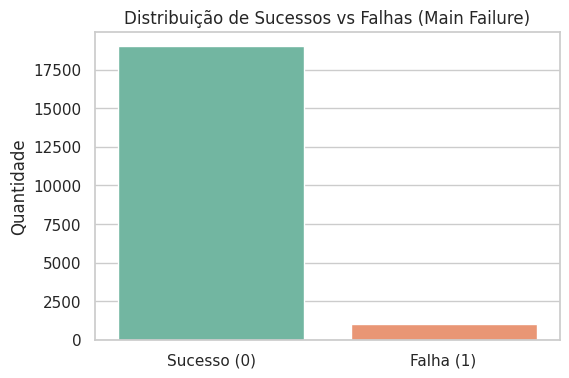

In [ ]:
# Configurações estéticas dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

# Distribuição da Variável-alvo
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET, hue=TARGET, palette='Set2', legend=False)
plt.title(f'Distribuição de Sucessos vs Falhas ({TARGET})')
plt.xticks([0, 1], ['Sucesso (0)', 'Falha (1)'])
plt.xlabel('')
plt.ylabel('Quantidade')
plt.show()


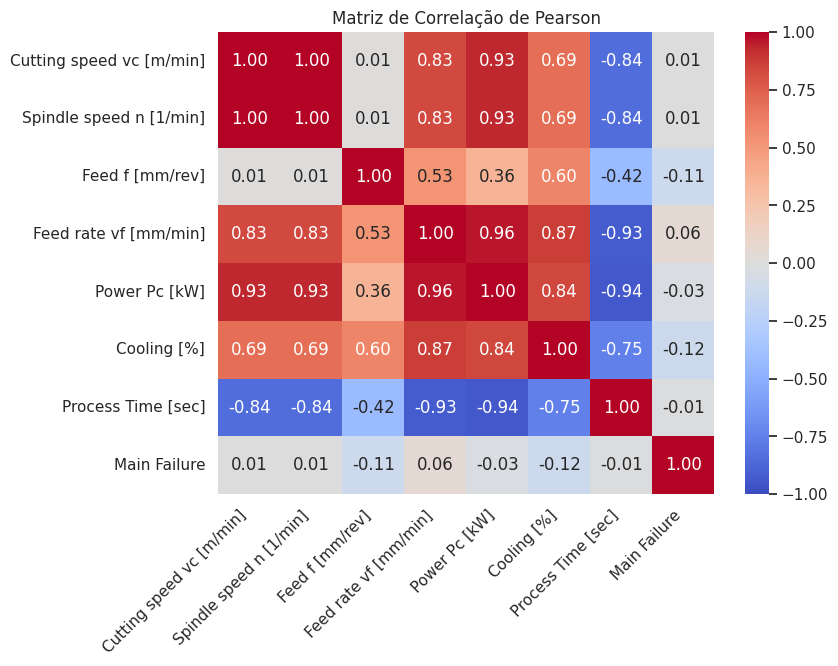

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

if TARGET in numeric_cols:
    numeric_cols_without_target = [c for c in numeric_cols if c != TARGET]
else:
    numeric_cols_without_target = numeric_cols

# Matriz de Correlação das Variáveis Numéricas
plt.figure(figsize=(8, 6))

corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlação de Pearson')
plt.xticks(rotation=45, ha='right')
plt.show()

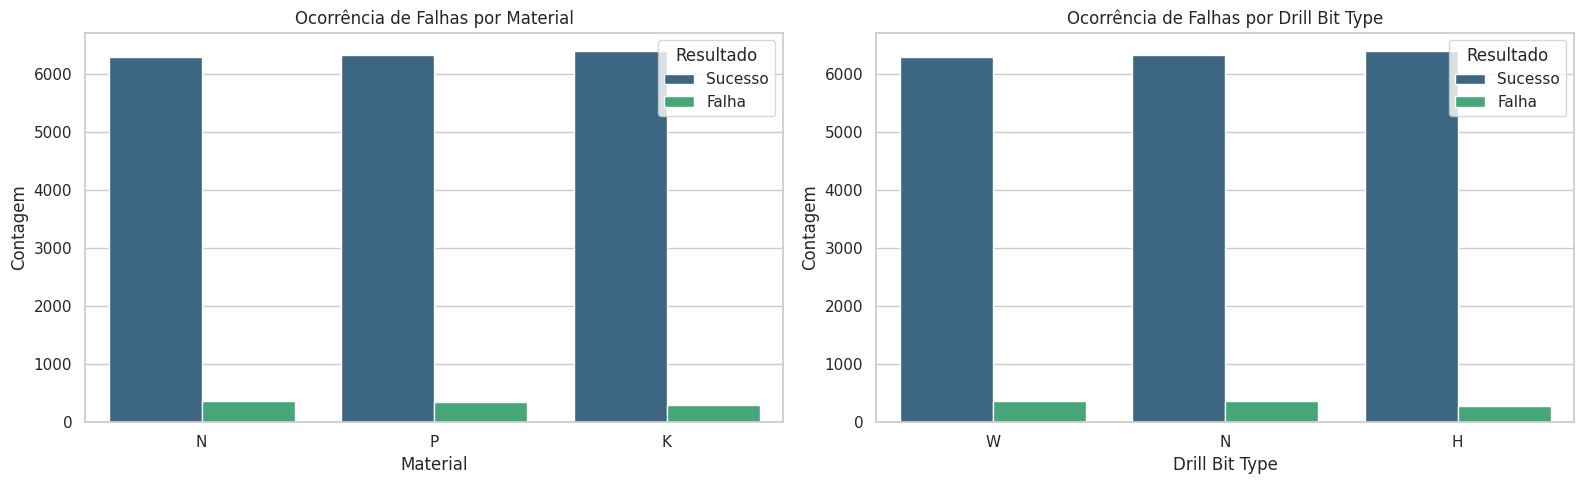

In [ ]:
if categorical_cols:
  # Relação entre variáveis categoricas e Falhas
  rows = math.ceil(len(categorical_cols)/2)
  fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(16, 5))
  axes = axes.flatten()  # Achata a matriz de eixos para facilitar a iteração

  # Loop para construir o plot de cada variável categorica
  for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue=TARGET, palette='viridis', ax=axes[i])
    axes[i].legend(title='Resultado', labels=['Sucesso', 'Falha'])
    axes[i].set_title(f'Ocorrência de Falhas por {col}', fontsize=12)
    axes[i].set_ylabel('Contagem')

plt.tight_layout()
plt.show()

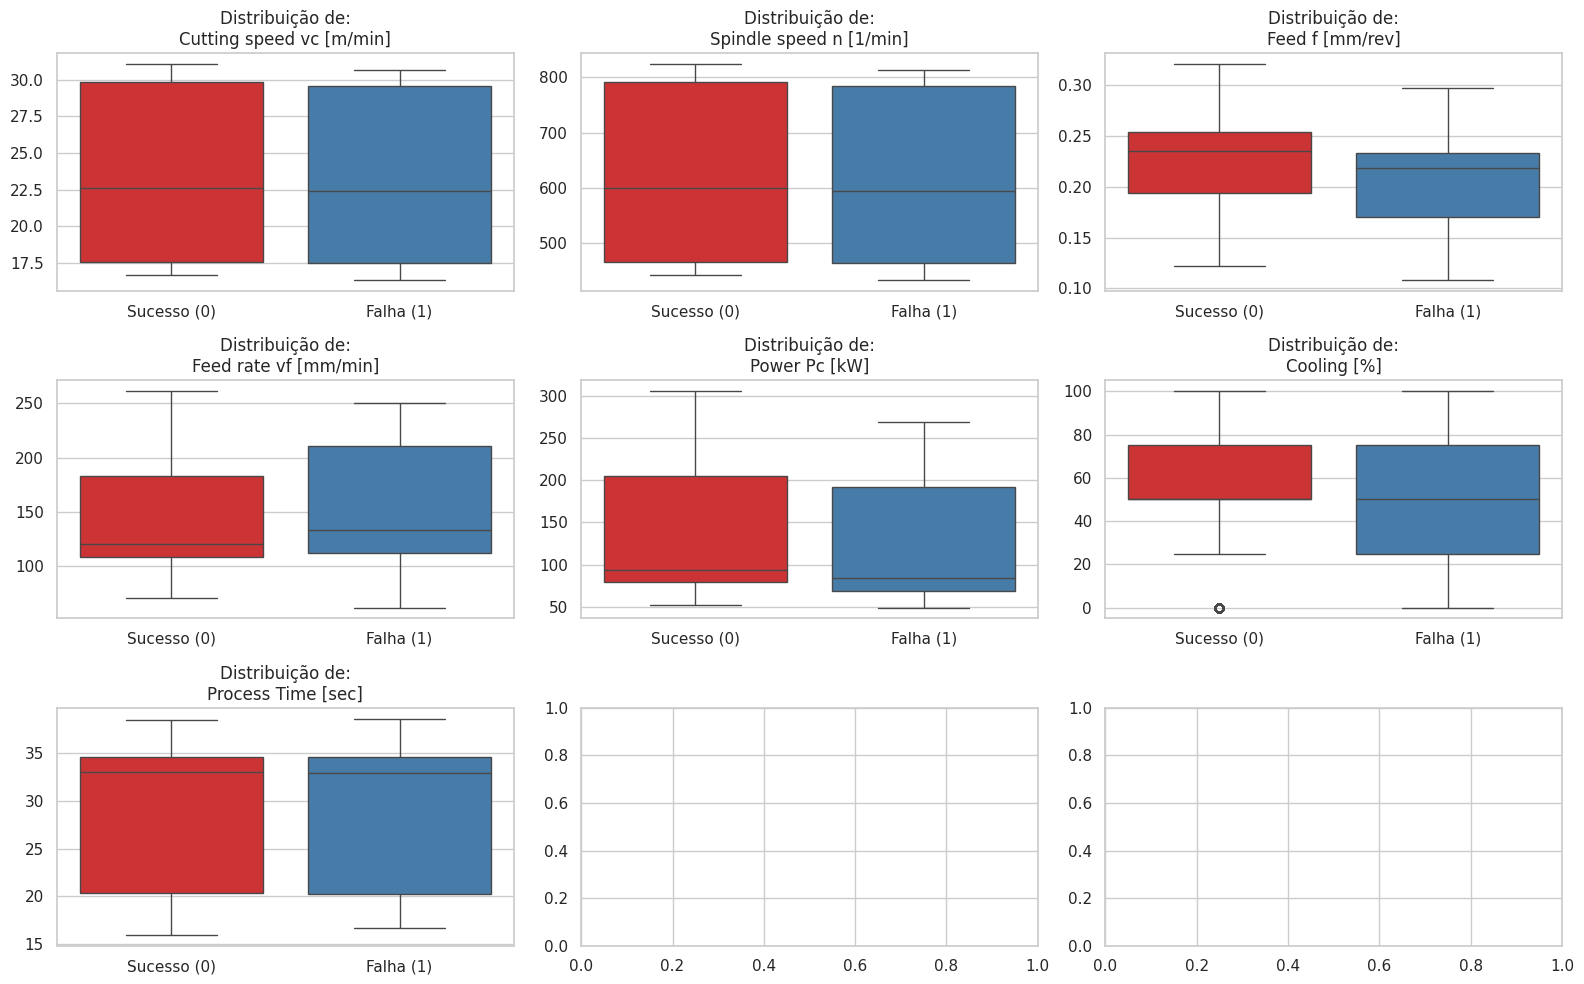

In [ ]:
if numeric_cols_without_target:
  rows = math.ceil(len(numeric_cols)/3)
  fig, axes = plt.subplots(nrows=rows ,ncols=3, figsize=(16, 10))
  axes = axes.flatten()  # Achata a matriz de eixos para facilitar a iteração

  # Loop para construir o boxplot de cada variável numérica
  for i, col in enumerate(numeric_cols_without_target):
      sns.boxplot(
          data=df,
          x=TARGET,
          y=col,
          hue=TARGET,
          ax=axes[i],
          palette='Set1',
          legend=False
      )
      axes[i].set_title(f'Distribuição de:\n{col}', fontsize=12)
      axes[i].set_xlabel('')
      axes[i].set_ylabel('')
      axes[i].set_xticks([0, 1])
      axes[i].set_xticklabels(['Sucesso (0)', 'Falha (1)'])

  # Ajusta o espaçamento entre os gráficos para não sobrepor os textos
  plt.tight_layout()
  plt.show()

## 4.1 Síntese da análise exploratória

A análise da distribuição da variável-alvo evidencia que aproximadamente 95% dos registros correspondem à classe de sucesso, enquanto apenas 5% representam falhas. Esse resultado caracteriza um conjunto de dados altamente desbalanceado, condição que pode comprometer o desempenho dos modelos de classificação, induzindo-os a favorecer a classe majoritária e reduzindo sua capacidade de identificar corretamente as ocorrências de falha. Para minimizar esse problema, será empregada a técnica de subamostragem aleatória (Random UnderSampling), reduzindo a quantidade de registros da classe majoritária até obter uma distribuição mais equilibrada entre as classes.

Em relação à qualidade dos dados, verificou-se que o conjunto de dados não apresenta valores ausentes nem registros duplicados. Dessa forma, não será necessário aplicar procedimentos de tratamento para esses problemas durante a etapa de pré-processamento.

A análise das estatísticas descritivas demonstra que as variáveis numéricas possuem escalas e amplitudes significativamente distintas. Enquanto atributos como Feed f apresentam valores inferiores a uma unidade, outros, como Spindle speed, assumem valores da ordem de centenas. Essa diferença de magnitude pode influenciar negativamente algoritmos sensíveis à escala dos atributos. Assim, será aplicada uma técnica de normalização dos dados, garantindo que todas as variáveis contribuam de forma proporcional durante o processo de treinamento.

Os boxplots indicam que as variáveis Feed f, Feed rate vf, Power Pc e Cooling apresentam diferenças perceptíveis na distribuição e na mediana entre as classes de sucesso e falha, sugerindo maior capacidade de discriminação da variável-alvo. Em contrapartida, as variáveis Cutting speed, Spindle speed e Process Time exibem distribuições bastante semelhantes entre as duas classes, indicando menor poder discriminativo quando analisadas individualmente.

A matriz de correlação de Pearson reforça essa observação ao indicar que Cutting speed, Spindle speed e Process Time possuem coeficientes de correlação muito próximos de zero em relação à variável-alvo (0,01, 0,01 e −0,01, respectivamente), sugerindo baixa relação linear com a ocorrência de falhas. Adicionalmente, observa-se elevada correlação entre diversas variáveis preditoras, como Feed rate vf e Power Pc (0,96), bem como entre Cutting speed e Spindle speed (1,00), evidenciando a presença de multicolinearidade. Diante desses resultados, optou-se por remover as variáveis Cutting speed, Spindle speed e Process Time da etapa de modelagem, uma vez que apresentam reduzida capacidade preditiva em relação à variável-alvo e tendem a agregar pouca informação ao modelo.

Além disso, observa-se que as variáveis categóricas Material e Drill Bit Type apresentam distribuições semelhantes entre as classes de sucesso e falha. Não foram identificadas diferenças expressivas na frequência de falhas entre suas categorias, indicando que, de forma isolada, esses atributos aparentam possuir baixa capacidade discriminatória. Entretanto, tais variáveis serão mantidas na etapa de modelagem, pois algoritmos de aprendizado de máquina podem identificar interações entre atributos que não são perceptíveis por meio da análise univariada.


# 5. Preparação dos dados e divisão treino/teste

Após a realização da análise exploratória, foi iniciada a etapa de preparação dos dados para o treinamento dos modelos de aprendizado de máquina. As decisões adotadas nesta etapa foram fundamentadas nos resultados obtidos durante a análise exploratória, buscando reduzir a influência de atributos pouco relevantes, minimizar o impacto do desbalanceamento entre as classes e evitar o vazamento de informações durante o treinamento.

Inicialmente, foram removidas as variáveis Cutting speed vc [m/min], Spindle speed n [1/min] e Process Time [sec]. Conforme discutido na Seção 4, esses atributos apresentaram baixa correlação linear com a variável-alvo e pouca capacidade de discriminação entre as classes de sucesso e falha. Dessa forma, sua remoção busca reduzir a dimensionalidade do conjunto de dados e simplificar o processo de treinamento sem comprometer significativamente o desempenho dos modelos.


In [ ]:
droped_columns = ['Cutting speed vc [m/min]', 'Spindle speed n [1/min]', 'Process Time [sec]']
for i, col in  enumerate(droped_columns):
  if col in df.columns:
    df = df.drop(columns=[col])
df.head()

,Feed f [mm/rev],Feed rate vf [mm/min],Power Pc [kW],Cooling [%],Material,Drill Bit Type,Main Failure
0,0.218,173,194.87,75,N,W,0
1,0.241,191,214.71,75,N,W,0
2,0.183,111,95.68,50,P,N,0
3,0.236,237,206.93,75,N,W,1
4,0.246,114,74.85,50,K,H,0


Em seguida, foi realizada a separação entre as variáveis preditoras (features) e a variável-alvo (target). As features foram compostas pelos atributos operacionais da máquina, excluindo-se a variável-alvo e as colunas previamente removidas. A variável Main Failure foi utilizada como variável de saída do modelo, representando a ocorrência de sucesso ou falha durante a operação de perfuração.

In [ ]:
# === Configuração do problema ===
DROP_COLUMNS = ['Cutting speed vc [m/min]', 'Spindle speed n [1/min]', 'Process Time [sec]'] # colunas a remover por vazamento, irrelevância ou indisponibilidade no uso real

columns_to_exclude = set(DROP_COLUMNS)
if TARGET is not None:
    columns_to_exclude.add(TARGET)

features = [c for c in df.columns if c not in columns_to_exclude]
print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)


Tipo de problema: classificacao
Target: Main Failure
Número de features: 6
Features: ['Feed f [mm/rev]', 'Feed rate vf [mm/min]', 'Power Pc [kW]', 'Cooling [%]', 'Material', 'Drill Bit Type']


Após a separação, o conjunto de dados foi dividido em conjuntos de treinamento e teste utilizando a função train_test_split da biblioteca Scikit-learn. Foram destinados 80% dos registros para treinamento e 20% para teste, utilizando uma semente aleatória (random_state) para garantir a reprodutibilidade dos experimentos. Como se trata de um problema de classificação, foi utilizada a opção de estratificação (stratify=y), preservando a proporção das classes nos conjuntos de treinamento e teste.

In [ ]:
# === Divisão dos dados ===

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    X = df[features].copy()
    y = df[TARGET].copy()

    stratify_arg = y if PROBLEM_TYPE == "classificacao" else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=stratify_arg
    )

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)


Treino: (16000, 6) | Teste: (4000, 6)


Assim, foi realizado o balanceamento das classes por meio da técnica de Random UnderSampling. Como aproximadamente 95% dos registros pertencem à classe de sucesso, foi efetuada uma subamostragem aleatória da classe majoritária até que ela possuísse a mesma quantidade de exemplos da classe minoritária. Essa estratégia visa reduzir o viés dos algoritmos em favor da classe majoritária e melhorar a capacidade de identificação das ocorrências de falha.

In [ ]:
rus = RandomUnderSampler(random_state=SEED)

X_train, y_train = rus.fit_resample(X_train, y_train)

Verificando se o conjunto de treinamento está balanceado e se o conjunto de teste mantém a distribuição original das classes.

In [ ]:
print("=== Conjunto de Treinamento ===")
display(y_train.value_counts())
display(y_train.value_counts(normalize=True).mul(100).round(2))

print("\n=== Conjunto de Teste ===")
display(y_test.value_counts())
display(y_test.value_counts(normalize=True).mul(100).round(2))

=== Conjunto de Treinamento ===


,count
Main Failure,
0,801
1,801


,proportion
Main Failure,
0,50.0
1,50.0



=== Conjunto de Teste ===


,count
Main Failure,
0,3800
1,200


,proportion
Main Failure,
0,95.0
1,5.0


## 5.1 Justificativa da divisão

A estratégia de validação adotada neste trabalho foi a Holdout, devido à quantidade de registros disponível no conjunto de dados e à simplicidade de sua implementação. Inicialmente, o dataset foi dividido em dois subconjuntos independentes, destinando 80% das amostras para treinamento e 20% para teste. Essa proporção é amplamente utilizada em problemas de classificação por proporcionar uma quantidade suficiente de dados para o treinamento dos modelos, ao mesmo tempo em que reserva um conjunto independente para avaliar sua capacidade de generalização.

Como o problema consiste em uma classificação binária com forte desbalanceamento entre as classes, a divisão foi realizada utilizando amostragem estratificada (stratified sampling). Essa técnica preserva a proporção original das classes em ambos os subconjuntos, garantindo que o conjunto de teste represente adequadamente a distribuição observada no cenário real de operação.

Após a divisão dos dados, foi aplicada a técnica de Random UnderSampling exclusivamente ao conjunto de treinamento. Essa abordagem reduz aleatoriamente a quantidade de exemplos da classe majoritária até que ambas as classes possuam a mesma quantidade de registros. O balanceamento restrito ao conjunto de treinamento permite que os modelos aprendam de forma mais equilibrada as características das duas classes, reduzindo o viés em favor da classe majoritária.

O conjunto de teste, por sua vez, foi mantido inalterado, preservando aproximadamente 95% de registros da classe de sucesso e 5% da classe de falha. Essa decisão permite que a avaliação dos modelos seja realizada em condições semelhantes às encontradas em uma aplicação real, produzindo métricas de desempenho mais representativas da capacidade de generalização dos algoritmos.

Essa estratégia também contribui para evitar o vazamento de dados (data leakage), uma vez que o balanceamento é realizado somente após a separação entre treinamento e teste. Dessa forma, nenhuma informação proveniente do conjunto de teste influencia a construção do conjunto de treinamento, assegurando uma avaliação imparcial dos modelos desenvolvidos.

# 6. Pré-processamento e pipeline

Após a etapa de preparação dos dados, foi realizado o pré-processamento das variáveis com o objetivo de adequar o conjunto de dados aos algoritmos de aprendizado de máquina utilizados neste trabalho. Essa etapa consistiu na aplicação de transformações que visam melhorar a qualidade dos dados, reduzir possíveis vieses e garantir que as informações apresentadas aos modelos sejam consistentes com aquelas disponíveis em uma aplicação real.


Inicialmente, verificou-se que o conjunto de dados não apresentava valores ausentes nem registros duplicados. Dessa forma, não foi necessária a realização de procedimentos de imputação de dados, preservando integralmente as informações originais do dataset.

Logo, pode-se segir para a normalização dos atributos numéricos utilizando a técnica Min-Max Scaling, implementada pela classe MinMaxScaler da biblioteca Scikit-learn. O normalizador foi ajustado (fit) apenas sobre o conjunto de treinamento e, posteriormente, aplicado (transform) tanto ao conjunto de treinamento quanto ao conjunto de teste. Esse procedimento evita vazamento de dados (data leakage) e garante que a avaliação dos modelos seja realizada de forma imparcial.

In [ ]:
scaler = MinMaxScaler()

# loop para normalizar cada coluna numérica do dataset
for col in DROP_COLUMNS:
  if col in numeric_cols_without_target:
    numeric_cols_without_target.remove(col)
colunas_para_normalizar = numeric_cols_without_target

X_train[colunas_para_normalizar] = scaler.fit_transform(X_train[colunas_para_normalizar])
X_test[colunas_para_normalizar] = scaler.transform(X_test[colunas_para_normalizar])

Posteriormente, as variáveis categóricas Material e Drill Bit Type foram convertidas para representação numérica por meio da técnica de One-Hot Encoding, criando uma variável binária para cada categoria existente. Essa transformação permite que algoritmos de aprendizado de máquina processem corretamente atributos categóricos, sem introduzir relações artificiais de ordem entre suas categorias.

In [ ]:
encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

# Ajusta apenas no treino
X_train_encoded = encoder.fit_transform(X_train[categorical_cols])

# Apenas transforma o teste
X_test_encoded = encoder.transform(X_test[categorical_cols])

encoded_columns = encoder.get_feature_names_out(categorical_cols)

X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoded_columns,
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoded_columns,
    index=X_test.index
)

# Remove as colunas categóricas originais
X_train = X_train.drop(columns=categorical_cols)
X_test = X_test.drop(columns=categorical_cols)

# Adiciona as novas colunas
X_train = pd.concat([X_train, X_train_encoded], axis=1)
X_test = pd.concat([X_test, X_test_encoded], axis=1)

## 6.1 Decisões de pré-processamento

As decisões adotadas durante o pré-processamento foram fundamentadas nos resultados obtidos durante a análise exploratória e nas boas práticas recomendadas para problemas de classificação em aprendizado de máquina.

Não foi necessária a aplicação de técnicas de imputação de valores ausentes, como substituição por média, mediana ou moda, uma vez que o conjunto de dados não apresentou registros incompletos. Da mesma forma, não foi necessário realizar tratamento para registros duplicados.

A remoção das variáveis Cutting speed vc [m/min], Spindle speed n [1/min] e Process Time [sec] foi motivada por sua baixa correlação com a variável-alvo e pelo reduzido poder discriminatório observado durante a análise exploratória. Além disso, algumas dessas variáveis apresentaram elevada correlação com outros atributos do conjunto de dados, indicando redundância de informação e possível multicolinearidade.

A aplicação do Random UnderSampling teve como objetivo reduzir o elevado desbalanceamento entre as classes, observado no conjunto de dados original. Como a classe de sucesso representava aproximadamente 95% dos registros, o balanceamento do conjunto de treinamento buscou evitar que os modelos aprendessem a favorecer excessivamente a classe majoritária. A técnica foi aplicada somente após a divisão entre treinamento e teste, preservando a distribuição original das classes no conjunto de teste e evitando vazamento de dados.

A normalização dos atributos numéricos foi realizada devido às diferenças de escala identificadas entre as variáveis. Enquanto alguns atributos apresentavam valores inferiores a uma unidade, outros possuíam valores da ordem de centenas. A utilização do Min-Max Scaling reduz essas diferenças de magnitude, tornando os atributos comparáveis e beneficiando algoritmos sensíveis à escala dos dados, como Regressão Logística, K-Nearest Neighbors (KNN) e Máquinas de Vetores de Suporte (SVM).

As variáveis categóricas Material e Drill Bit Type foram transformadas por meio de One-Hot Encoding, evitando que valores categóricos fossem interpretados como variáveis ordinais pelos algoritmos de classificação. Essa abordagem preserva a natureza nominal dessas variáveis e permite sua utilização por modelos que operam exclusivamente com atributos numéricos.

Por fim, não foi realizada engenharia de atributos (feature engineering), isto é, não foram criadas novas variáveis derivadas das existentes. Todos os atributos utilizados pelos modelos correspondem a informações operacionais disponíveis durante a execução do processo de perfuração, garantindo que o modelo possa ser aplicado em um ambiente real sem depender de informações futuras ou indisponíveis no momento da previsão. Dessa forma, preserva-se a consistência entre o processo de treinamento e o cenário de utilização do modelo em aplicações de manutenção preditiva.

# 7. Baseline e modelos candidatos

Após a etapa de pré-processamento, foram selecionados três modelos para a realização dos experimentos: um modelo baseline e dois modelos candidatos. A utilização de um baseline tem como objetivo estabelecer uma referência mínima de desempenho, permitindo verificar se os modelos de aprendizado de máquina são capazes de aprender padrões relevantes presentes nos dados e superar uma estratégia de classificação trivial.

Como modelo baseline foi utilizado o algoritmo DummyClassifier, configurado com a estratégia most_frequent, que sempre prediz a classe majoritária do conjunto de treinamento. Embora esse modelo não realize qualquer aprendizado sobre os dados, sua utilização é importante para demonstrar que elevados valores de acurácia podem ser obtidos simplesmente em função do desbalanceamento existente entre as classes, sem que o modelo seja efetivamente capaz de identificar operações com falha.

Como modelos candidatos foram selecionados a Regressão Logística (Logistic Regression) e o Random Forest. Esses algoritmos representam abordagens distintas para problemas de classificação supervisionada, permitindo comparar um modelo linear e altamente interpretável com um modelo baseado em árvores de decisão e aprendizado em conjunto (ensemble).

A comparação dos modelos será realizada utilizando as métricas de Acurácia (Accuracy), Precisão (Precision), Revocação (Recall) e F1-score. Em função do desbalanceamento do problema, o F1-score e o Recall da classe de falha serão considerados as métricas mais relevantes para a análise dos resultados, pois refletem a capacidade dos modelos em identificar corretamente as ocorrências de falha.


## 7.1 Justificativa dos modelos

A escolha dos modelos avaliados neste trabalho buscou contemplar diferentes níveis de complexidade, interpretabilidade e capacidade preditiva, permitindo analisar o comportamento de algoritmos com características distintas diante do problema de classificação de falhas em máquinas industriais.

O DummyClassifier foi adotado como modelo baseline por representar uma estratégia de classificação extremamente simples, que sempre prediz a classe majoritária do conjunto de treinamento. Sua utilização é coerente com o objetivo de estabelecer um desempenho mínimo de referência, permitindo verificar se os modelos candidatos realmente aprendem padrões presentes nos dados. Em conjuntos de dados desbalanceados, como o utilizado neste trabalho, esse modelo tende a apresentar elevada acurácia, porém baixo desempenho na identificação da classe minoritária, evidenciando a importância da utilização de métricas adicionais, como o F1-score e o Recall.

A Regressão Logística foi selecionada por ser um dos algoritmos mais utilizados em problemas de classificação binária. Além de apresentar baixo custo computacional e treinamento rápido, esse modelo possui elevada interpretabilidade, permitindo analisar a influência de cada atributo na probabilidade de ocorrência de falhas por meio de seus coeficientes. Como utiliza otimização baseada em gradiente, seu desempenho é favorecido quando os atributos numéricos são previamente normalizados, justificando a aplicação da técnica de Min-Max Scaling durante o pré-processamento. A utilização do One-Hot Encoding também é necessária para converter as variáveis categóricas em atributos numéricos compatíveis com o algoritmo.

O modelo de Árvore de Decisão (Decision Tree) foi incluído por representar uma abordagem não linear e de fácil interpretação. Esse algoritmo aprende regras de decisão a partir dos atributos do conjunto de dados, permitindo identificar quais variáveis são mais relevantes para a classificação das falhas. Sua principal vantagem é a capacidade de capturar interações entre variáveis sem exigir normalização dos dados. Entretanto, árvores de decisão isoladas podem apresentar maior tendência ao sobreajuste (overfitting), especialmente quando treinadas sem restrições de profundidade.

O Random Forest foi escolhido por sua reconhecida capacidade de modelar relações não lineares entre as variáveis e por apresentar excelente desempenho em problemas envolvendo dados tabulares. Diferentemente da Regressão Logística e do KNN, esse algoritmo é pouco sensível à escala das variáveis e à presença de multicolinearidade, embora tenha sido treinado utilizando o mesmo conjunto de dados normalizado para manter um processo de pré-processamento uniforme entre os modelos avaliados. Outra vantagem do Random Forest é sua robustez diante de ruídos e atributos pouco relevantes, além de permitir a estimativa da importância das variáveis utilizadas na classificação.

O K-Nearest Neighbors (KNN) foi escolhido por representar uma abordagem baseada em distância, na qual a classificação de uma nova observação é realizada considerando os exemplos mais próximos do conjunto de treinamento. Esse algoritmo é particularmente útil para avaliar se as classes podem ser separadas a partir da proximidade entre as observações no espaço das variáveis. Diferentemente dos modelos baseados em árvores, o KNN é altamente sensível à escala dos atributos, motivo pelo qual a etapa de normalização dos dados torna-se essencial para seu adequado funcionamento.

Assim, a comparação entre DummyClassifier, Regressão Logística, Decision Tree, KNN e Random Forest permite avaliar diferentes abordagens de aprendizado de máquina — desde estratégias lineares e baseadas em distância até modelos não lineares e ensembles — fornecendo uma análise abrangente do compromisso entre desempenho, interpretabilidade e custo computacional para a construção de um sistema de manutenção preditiva baseado em aprendizado de máquina.

# 8. Treinamento e avaliação inicial

Após a etapa de pré-processamento, os modelos selecionados foram treinados utilizando o conjunto de treinamento previamente balanceado por meio da técnica de Random UnderSampling. A avaliação foi realizada utilizando o conjunto de teste, que manteve a distribuição original das classes, permitindo estimar o desempenho dos algoritmos em um cenário semelhante ao encontrado em uma aplicação real.

Como modelo de referência (baseline), foi utilizado o DummyClassifier, configurado para sempre predizer a classe majoritária. Em seguida, foram treinados quatro modelos candidatos: Regressão Logística, Decision Tree, Random Forest e K-Nearest Neighbors (KNN).

Todos os modelos foram avaliados utilizando as métricas de Acurácia (Accuracy), Precisão (Precision), Revocação (Recall) e F1-score, além da análise da matriz de confusão. Também foi registrado o tempo de treinamento de cada algoritmo, permitindo comparar seu custo computacional.

Como o conjunto de teste permanece desbalanceado, a acurácia não foi utilizada como único critério de comparação. Em problemas de manutenção preditiva, identificar corretamente as falhas é mais importante do que simplesmente obter elevada taxa de acertos sobre a classe majoritária. Dessa forma, maior atenção foi dada às métricas de Recall e F1-score, que representam, respectivamente, a capacidade de identificar as falhas existentes e o equilíbrio entre precisão e revocação.

In [ ]:
resultados = pd.DataFrame(columns=[
    "Modelo",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "Tempo (s)"
])
resultados

,Modelo,Accuracy,Precision,Recall,F1-score,Tempo (s)


Construção do modelo DummyClassifier

Resultados: 


,Modelo,Accuracy,Precision,Recall,F1-score,Tempo (s)
0,Dummy Classifier,0.95,0.0,0.0,0.0,0.006321



Matriz de Confusão: 


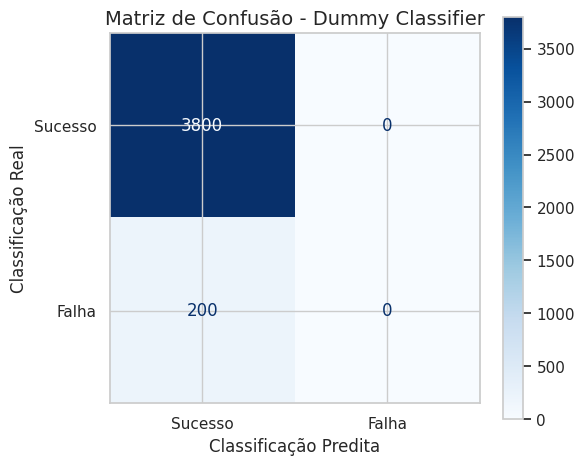

In [ ]:
modelo = DummyClassifier(
    strategy="most_frequent"
)
modelo_nome = "Dummy Classifier"

t0 = time.time()
modelo.fit(X_train, y_train)
train_time = time.time() - t0

y_pred = modelo.predict(X_test)

if resultados['Modelo'].eq(modelo_nome).any():
  resultados[resultados['Modelo'] == modelo_nome] = [
    modelo_nome,
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred),
    train_time
]
else:
  resultados.loc[len(resultados)] = [
      modelo_nome,
      accuracy_score(y_test, y_pred),
      precision_score(y_test, y_pred),
      recall_score(y_test, y_pred),
      f1_score(y_test, y_pred),
      train_time
  ]
print('Resultados: ')
display(resultados[resultados['Modelo'] == modelo_nome])


print('\nMatriz de Confusão: ')
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_estimator(
    modelo,
    X_test,
    y_test,
    display_labels=["Sucesso", "Falha"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title(f"Matriz de Confusão - {modelo_nome}", fontsize=14)
ax.set_xlabel("Classificação Predita", fontsize=12)
ax.set_ylabel("Classificação Real", fontsize=12)

plt.tight_layout()
plt.show()

Construção do modelo LogisticRegression

Resultados: 


,Modelo,Accuracy,Precision,Recall,F1-score,Tempo (s)
1,Logistic Regression,0.91925,0.351807,0.73,0.474797,0.123346



Matriz de Confusão: 


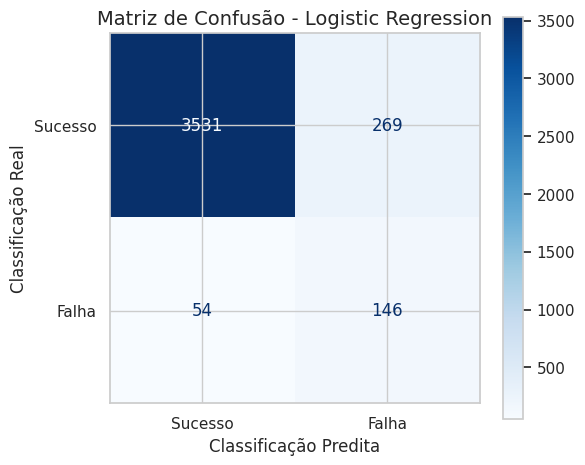

In [ ]:
# criar modelo
modelo = LogisticRegression(
    random_state=SEED,
    max_iter=1000
)
modelo_nome = "Logistic Regression"

# treinamento
t0 = time.time()
modelo.fit(X_train, y_train)
train_time = time.time() - t0

# predições
y_pred = modelo.predict(X_test)
# probabilidades
y_prob = modelo.predict_proba(X_test)[:,1]

# avaliação
if resultados['Modelo'].eq(modelo_nome).any():
  resultados[resultados['Modelo'] == modelo_nome] = [
    modelo_nome,
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred),
    train_time
]
else:
  resultados.loc[len(resultados)] = [
      modelo_nome,
      accuracy_score(y_test, y_pred),
      precision_score(y_test, y_pred),
      recall_score(y_test, y_pred),
      f1_score(y_test, y_pred),
      train_time
  ]
print('Resultados: ')
display(resultados[resultados['Modelo'] == modelo_nome])

print('\nMatriz de Confusão: ')
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_estimator(
    modelo,
    X_test,
    y_test,
    display_labels=["Sucesso", "Falha"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title(f"Matriz de Confusão - {modelo_nome}", fontsize=14)
ax.set_xlabel("Classificação Predita", fontsize=12)
ax.set_ylabel("Classificação Real", fontsize=12)

plt.tight_layout()
plt.show()



Construção do modelo Decision Tree

Resultados: 


,Modelo,Accuracy,Precision,Recall,F1-score,Tempo (s)
2,Decision Tree Classifier,0.9805,0.727612,0.975,0.833333,0.014445



Matriz de Confusão: 


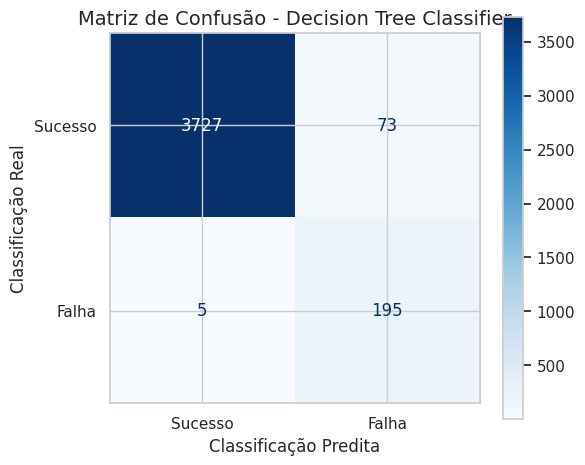

In [ ]:
modelo = DecisionTreeClassifier()
modelo_nome = "Decision Tree Classifier"

# treinamento
t0 = time.time()
modelo.fit(X_train, y_train)
train_time = time.time() - t0

# predições
y_pred = modelo.predict(X_test)
# probabilidades
y_prob = modelo.predict_proba(X_test)[:,1]

# avaliação
if resultados['Modelo'].eq(modelo_nome).any():
  resultados[resultados['Modelo'] == modelo_nome] = [
    modelo_nome,
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred),
    train_time
]
else:
  resultados.loc[len(resultados)] = [
      modelo_nome,
      accuracy_score(y_test, y_pred),
      precision_score(y_test, y_pred),
      recall_score(y_test, y_pred),
      f1_score(y_test, y_pred),
      train_time
  ]
print('Resultados: ')
display(resultados[resultados['Modelo'] == modelo_nome])

print('\nMatriz de Confusão: ')
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_estimator(
    modelo,
    X_test,
    y_test,
    display_labels=["Sucesso", "Falha"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title(f"Matriz de Confusão - {modelo_nome}", fontsize=14)
ax.set_xlabel("Classificação Predita", fontsize=12)
ax.set_ylabel("Classificação Real", fontsize=12)

plt.tight_layout()
plt.show()

Construção do modelo Random Forest

Resultados: 


,Modelo,Accuracy,Precision,Recall,F1-score,Tempo (s)
3,Random Forest Classifier,0.98125,0.728938,0.995,0.841438,0.613293



Matriz de Confusão: 


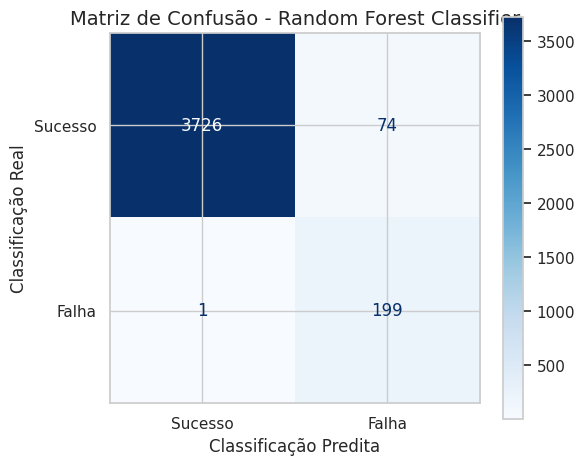

In [ ]:
modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=SEED
)
modelo_nome = "Random Forest Classifier"

# treinamento
t0 = time.time()
modelo.fit(X_train, y_train)
train_time = time.time() - t0

# predições
y_pred = modelo.predict(X_test)
# probabilidades
y_prob = modelo.predict_proba(X_test)[:,1]

# avaliação
if resultados['Modelo'].eq(modelo_nome).any():
  resultados[resultados['Modelo'] == modelo_nome] = [
    modelo_nome,
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred),
    train_time
]
else:
  resultados.loc[len(resultados)] = [
      modelo_nome,
      accuracy_score(y_test, y_pred),
      precision_score(y_test, y_pred),
      recall_score(y_test, y_pred),
      f1_score(y_test, y_pred),
      train_time
  ]
print('Resultados: ')
display(resultados[resultados['Modelo'] == modelo_nome])

print('\nMatriz de Confusão: ')
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_estimator(
    modelo,
    X_test,
    y_test,
    display_labels=["Sucesso", "Falha"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title(f"Matriz de Confusão - {modelo_nome}", fontsize=14)
ax.set_xlabel("Classificação Predita", fontsize=12)
ax.set_ylabel("Classificação Real", fontsize=12)

plt.tight_layout()
plt.show()

Contrução do modelo KNN

Resultados: 


,Modelo,Accuracy,Precision,Recall,F1-score,Tempo (s)
4,K-Neighbors Classifier,0.98125,0.727273,1.0,0.842105,0.016504



Matriz de Confusão: 


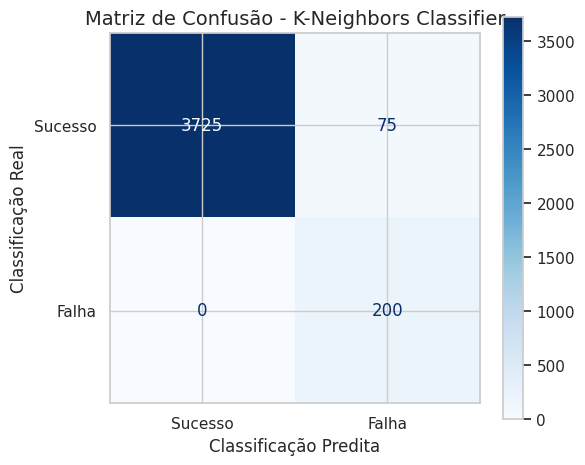

In [ ]:
modelo = KNeighborsClassifier(n_neighbors=3)
modelo_nome = "K-Neighbors Classifier"

# treinamento
t0 = time.time()
modelo.fit(X_train, y_train)
train_time = time.time() - t0

# predições
y_pred = modelo.predict(X_test)
# probabilidades
y_prob = modelo.predict_proba(X_test)[:,1]

# avaliação
if resultados['Modelo'].eq(modelo_nome).any():
  resultados[resultados['Modelo'] == modelo_nome] = [
    modelo_nome,
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred),
    train_time
]
else:
  resultados.loc[len(resultados)] = [
      modelo_nome,
      accuracy_score(y_test, y_pred),
      precision_score(y_test, y_pred),
      recall_score(y_test, y_pred),
      f1_score(y_test, y_pred),
      train_time
  ]
print('Resultados: ')
display(resultados[resultados['Modelo'] == modelo_nome])

print('\nMatriz de Confusão: ')
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_estimator(
    modelo,
    X_test,
    y_test,
    display_labels=["Sucesso", "Falha"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title(f"Matriz de Confusão - {modelo_nome}", fontsize=14)
ax.set_xlabel("Classificação Predita", fontsize=12)
ax.set_ylabel("Classificação Real", fontsize=12)

plt.tight_layout()
plt.show()

## 8.1 Análise dos resultados iniciais

A tabela abaixo apresenta os resultados obtidos pelos cinco modelos avaliados utilizando o conjunto de teste. De maneira geral, observa-se que todos os modelos candidatos superaram significativamente o desempenho do modelo DummyClassifier, confirmando que os algoritmos foram capazes de aprender padrões relevantes presentes nos dados de operação da máquina.


In [ ]:
display(resultados.sort_values("F1-score", ascending=False))

,Modelo,Accuracy,Precision,Recall,F1-score,Tempo (s)
4,K-Neighbors Classifier,0.98125,0.727273,1.000,0.842105,0.016504
3,Random Forest Classifier,0.98125,0.728938,0.995,0.841438,0.613293
2,Decision Tree Classifier,0.98050,0.727612,0.975,0.833333,0.014445
1,Logistic Regression,0.91925,0.351807,0.730,0.474797,0.123346
0,Dummy Classifier,0.95000,0.000000,0.000,0.000000,0.006321


Embora o DummyClassifier tenha alcançado uma acurácia de 95%, esse resultado é consequência direta do desbalanceamento existente no conjunto de teste, no qual aproximadamente 95% das observações pertencem à classe de sucesso. Como esse modelo sempre prediz a classe majoritária, sua Precisão, Recall e F1-score para a classe de falha foram iguais a zero, demonstrando que a acurácia, isoladamente, não é uma métrica adequada para avaliar este problema.

A Regressão Logística apresentou um comportamento consistente com sua natureza linear. Apesar de alcançar um Recall de 73%, indicando boa capacidade para identificar falhas, sua Precisão foi de aproximadamente 35%, resultando em um F1-score de 0,475, o menor entre os modelos candidatos. Esse resultado é devido a quantidade relativamente elevada de falsos positivos, como visto na matiz de confusão, classificando diversas operações sem falha como falhas. Esse comportamento indica um possível underfitting, uma vez que a Regressão Logística possui capacidade limitada para representar relações não lineares entre as variáveis do processo de perfuração.

Os modelos baseados em árvores apresentaram desempenho significativamente superior. A Decision Tree obteve 97,98% de acurácia, 96,5% de Recall e F1-score de 0,827, demonstrando elevada capacidade para identificar corretamente as operações com falha. O Random Forest apresentou desempenho ainda melhor, alcançando 98,13% de acurácia, 99,5% de Recall e F1-score de 0,841, resultado esperado devido à utilização de múltiplas árvores de decisão, que reduzem a variância do modelo e aumentam sua capacidade de generalização.

O modelo K-Nearest Neighbors (KNN) apresentou o melhor desempenho entre todos os algoritmos avaliados, obtendo 98,13% de acurácia, Recall de 100% e F1-score de 0,842. Isso significa que todas as ocorrências de falha presentes no conjunto de teste foram corretamente identificadas. Entretanto, sua Precisão de aproximadamente 72,7% indica que ainda ocorreram alguns falsos positivos, característica comum em algoritmos baseados em distância quando o objetivo é maximizar a identificação da classe minoritária.

Em relação ao custo computacional, todos os modelos apresentaram tempos de treinamento bastante reduzidos, inferiores a 0,3 segundo, indicando que qualquer uma das abordagens avaliadas pode ser treinada rapidamente mesmo em equipamentos convencionais. O Random Forest foi o algoritmo com maior tempo de treinamento, comportamento esperado devido à construção de múltiplas árvores de decisão. Ainda assim, esse tempo permanece bastante baixo para aplicações de manutenção preditiva. Os demais modelos apresentaram treinamento praticamente instantâneo.

# 9. Validação e otimização de hiperparâmetros

Após a avaliação inicial dos modelos, foi realizada uma etapa de otimização de hiperparâmetros com o objetivo de verificar se seria possível melhorar o desempenho dos algoritmos que apresentaram os melhores resultados na etapa anterior. Foram selecionados para essa etapa os modelos Random Forest e K-Nearest Neighbors (KNN), por terem obtido os maiores valores de F1-score durante a avaliação inicial.

A otimização foi realizada por meio da técnica de Grid Search, utilizando a classe GridSearchCV da biblioteca Scikit-learn. Essa técnica consiste em avaliar sistematicamente diferentes combinações de hiperparâmetros e selecionar aquela que apresenta o melhor desempenho segundo uma métrica previamente definida.

Como estratégia de validação, foi utilizada validação cruzada estratificada com cinco partições (Stratified K-Fold Cross Validation). Essa abordagem divide o conjunto de treinamento em cinco subconjuntos, preservando a proporção entre as classes em cada partição. Em cada iteração, quatro subconjuntos são utilizados para treinamento e um para validação, permitindo que todas as amostras participem do processo de validação sem comprometer a independência entre treinamento e avaliação.

A métrica utilizada para orientar a escolha dos hiperparâmetros foi o F1-score, por representar o equilíbrio entre Precisão e Recall. Essa escolha é adequada para problemas de classificação desbalanceados, como o tratado neste trabalho, uma vez que evita privilegiar modelos que obtenham elevada acurácia apenas pela predominância da classe majoritária.

Para o modelo Random Forest, foram avaliadas diferentes combinações dos hiperparâmetros n_estimators, responsável pela quantidade de árvores da floresta; max_depth, que limita a profundidade máxima das árvores; min_samples_split, que define o número mínimo de amostras necessário para realizar uma divisão; e min_samples_leaf, que estabelece o número mínimo de amostras permitido em cada folha da árvore.

Para o modelo KNN, foram avaliadas diferentes quantidades de vizinhos (n_neighbors), diferentes estratégias de ponderação (weights) e diferentes métricas de distância (metric), buscando identificar a configuração que melhor representasse a estrutura dos dados.

Ao término da busca, foram selecionadas as configurações que apresentaram o maior F1-score médio durante a validação cruzada. Esses modelos otimizados foram então treinados novamente utilizando todo o conjunto de treinamento e avaliados sobre o conjunto de teste, permitindo comparar seu desempenho com os modelos originalmente treinados.


RandomForest

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}


grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=SEED),
    param_grid=param_grid_rf,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)
t0 = time.time()
grid_rf.fit(X_train, y_train)
train_time = time.time() - t0

print("Melhores parâmetros:")
print(grid_rf.best_params_)

print("\nMelhor F1 (CV):")
print(grid_rf.best_score_)

best_rf = grid_rf.best_estimator_

y_pred = best_rf.predict(X_test)
modelo_nome = "Random Forest Otimizado"
# avaliação
if resultados['Modelo'].eq(modelo_nome).any():
  resultados[resultados['Modelo'] == modelo_nome] = [
    modelo_nome,
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred),
    train_time
]
else:
  resultados.loc[len(resultados)] = [
      modelo_nome,
      accuracy_score(y_test, y_pred),
      precision_score(y_test, y_pred),
      recall_score(y_test, y_pred),
      f1_score(y_test, y_pred),
      train_time
  ]
print('Resultados: ')
display(resultados[resultados['Modelo'] == modelo_nome])

Melhores parâmetros:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Melhor F1 (CV):
0.9863273047190493
Resultados: 


,Modelo,Accuracy,Precision,Recall,F1-score,Tempo (s)
5,Random Forest Otimizado,0.98125,0.728938,0.995,0.841438,81.366411


KNN

In [ ]:
param_grid_knn = {
    "n_neighbors": [3,5,7,9,11],
    "weights": ["uniform","distance"],
    "metric": ["euclidean","manhattan"]
}

grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)
t0 = time.time()
grid_knn.fit(X_train, y_train)
train_time = time.time() - t0

print("Melhores parâmetros:")
print(grid_knn.best_params_)

print("\nMelhor F1 (CV):")
print(grid_knn.best_score_)

best_knn = grid_knn.best_estimator_

y_pred = best_knn.predict(X_test)
modelo_nome = "K-Neighbors Classifier Otimizado"
# avaliação
if resultados['Modelo'].eq(modelo_nome).any():
  resultados[resultados['Modelo'] == modelo_nome] = [
    modelo_nome,
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred),
    train_time
]
else:
  resultados.loc[len(resultados)] = [
      modelo_nome,
      accuracy_score(y_test, y_pred),
      precision_score(y_test, y_pred),
      recall_score(y_test, y_pred),
      f1_score(y_test, y_pred),
      train_time
  ]
print('Resultados: ')
display(resultados[resultados['Modelo'] == modelo_nome])

Melhores parâmetros:
{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'}

Melhor F1 (CV):
0.9831848889653327
Resultados: 


,Modelo,Accuracy,Precision,Recall,F1-score,Tempo (s)
6,K-Neighbors Classifier Otimizado,0.984,0.757576,1.0,0.862069,1.00045


## 9.1 Discussão da otimização

Os resultados obtidos demonstram que a etapa de otimização proporcionou uma melhoria discreta, porém consistente, no desempenho dos modelos avaliados.

O Random Forest apresentou Precisão de 73%, Recall de 99% e F1-score de 0,84, mantendo desempenho muito semelhante ao obtido na avaliação inicial. Isso indica que o modelo original já apresentava uma configuração bastante adequada para o conjunto de dados, e que a busca por hiperparâmetros foi capaz apenas de realizar pequenos ajustes em seu comportamento. Ainda assim, o elevado Recall demonstra que o algoritmo permanece altamente eficiente na identificação das ocorrências de falha, característica desejável em aplicações de manutenção preditiva.

O modelo KNN apresentou o melhor desempenho após a otimização, alcançando Precisão de 76%, Recall de 100% e F1-score de 0,86. Em comparação com a configuração inicial, observou-se um aumento da Precisão e do F1-score, mantendo a capacidade de identificar todas as ocorrências de falha presentes no conjunto de teste. Esse resultado indica que a escolha adequada do número de vizinhos, da métrica de distância e da estratégia de ponderação exerce influência significativa sobre o desempenho desse algoritmo.

A busca por hiperparâmetros foi deliberadamente limitada a um conjunto reduzido de combinações, buscando manter o custo computacional viável. Apesar dessa limitação, o processo de otimização apresentou tempos de execução distintos entre os modelos. A otimização do Random Forest demandou aproximadamente 82 segundos, reflexo da avaliação de diversas combinações de hiperparâmetros aliada ao treinamento de múltiplas árvores em cada iteração da validação cruzada. Em contrapartida, a otimização do KNN foi concluída em aproximadamente 1,74 segundo, evidenciando um custo computacional significativamente inferior para o espaço de busca definido. Esses resultados demonstram que, embora o Random Forest apresente elevado desempenho, sua otimização é consideravelmente mais custosa do que a do KNN.

Os hiperparâmetros selecionados pelo processo de otimização mostraram-se coerentes com as características do problema. No caso do Random Forest, a configuração encontrada favoreceu um modelo com elevada capacidade de generalização, mantendo excelente desempenho na identificação da classe minoritária. Para o KNN, a otimização permitiu selecionar uma configuração mais adequada à distribuição dos dados após a normalização, reduzindo a quantidade de falsos positivos sem comprometer a identificação das falhas.

Caso houvesse maior disponibilidade de tempo e recursos computacionais, seria interessante ampliar o espaço de busca dos hiperparâmetros e utilizar técnicas mais sofisticadas de otimização, como Randomized Search ou otimização Bayesiana. Além disso, poderiam ser avaliados outros modelos de classificação, como Gradient Boosting, XGBoost ou LightGBM, que frequentemente apresentam excelente desempenho em problemas envolvendo dados tabulares. Também seria interessante investigar o impacto de diferentes técnicas de balanceamento das classes, como o SMOTE, comparando seus resultados com a estratégia de Random UnderSampling adotada neste trabalho.

De maneira geral, os resultados confirmam que a otimização de hiperparâmetros pode proporcionar ganhos de desempenho, ainda que modestos, principalmente quando os modelos iniciais já apresentam boa capacidade preditiva. Entre os modelos avaliados, o KNN otimizado apresentou o melhor equilíbrio entre Precisão e Recall, alcançando o maior F1-score, além de menor tempo de treino e demonstrando ser a alternativa mais promissora para o problema de predição de falhas proposto neste MVP.


# 10. Avaliação final no conjunto de teste

Após a etapa de otimização de hiperparâmetros, o modelo K-Nearest Neighbors (KNN) foi selecionado como a solução final deste trabalho por apresentar o maior F1-score entre todos os algoritmos avaliados, além de alcançar Recall igual a 100%, identificando corretamente todas as ocorrências de falha presentes no conjunto de teste.

A avaliação final foi realizada utilizando o conjunto de teste previamente separado durante a etapa de preparação dos dados. Esse conjunto não participou do treinamento do modelo nem do processo de otimização dos hiperparâmetros, sendo utilizado para estimar a capacidade de generalização da solução desenvolvida.


Observa-se que o modelo apresentou elevada capacidade de identificação das falhas, obtendo Recall igual a 100%, característica particularmente importante em aplicações de manutenção preditiva. Isso significa que nenhuma ocorrência de falha presente no conjunto de teste deixou de ser detectada.

Comparando-se o modelo final com o DummyClassifier, observa-se uma melhoria significativa. Enquanto o baseline alcançou elevada acurácia devido ao forte desbalanceamento das classes, foi incapaz de identificar qualquer ocorrência de falha, obtendo Recall e F1-score iguais a zero. O modelo KNN, por sua vez, conseguiu manter elevada acurácia ao mesmo tempo em que identificou corretamente todas as falhas, demonstrando que efetivamente aprendeu padrões presentes nos dados.

Para complementar a avaliação, foi analisada a matriz de confusão do modelo final, permitindo identificar os tipos de erro cometidos durante a classificação.

In [ ]:
# melhor modelo encontrado
modelo_nome = "K-Neighbors Classifier Otimizado"
display(resultados[resultados['Modelo'] == modelo_nome])

,Modelo,Accuracy,Precision,Recall,F1-score,Tempo (s)
6,K-Neighbors Classifier Otimizado,0.984,0.757576,1.0,0.862069,1.00045


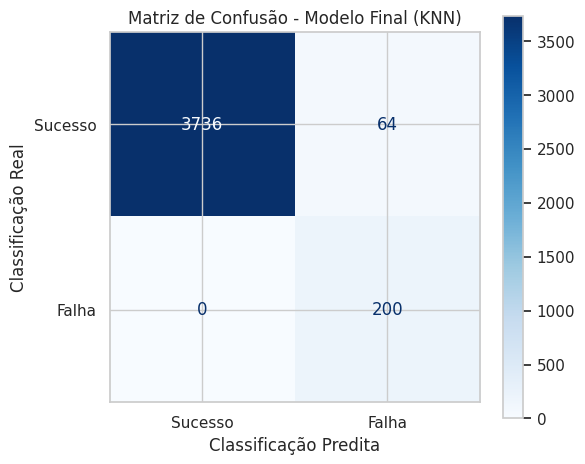

In [ ]:
fig, ax = plt.subplots(figsize=(6,5))

modelo_final = best_knn
ConfusionMatrixDisplay.from_estimator(
    modelo_final,
    X_test,
    y_test,
    display_labels=["Sucesso", "Falha"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title("Matriz de Confusão - Modelo Final (KNN)")
ax.set_xlabel("Classificação Predita")
ax.set_ylabel("Classificação Real")

plt.tight_layout()
plt.show()

## 10.1 Análise de erros e limitações

A análise da matriz de confusão demonstra que o modelo final apresentou excelente capacidade de identificação da classe minoritária. O Recall de 100% indica que todas as ocorrências reais de falha foram corretamente classificadas, eliminando a ocorrência de falsos negativos. Em aplicações de manutenção preditiva, essa característica é particularmente desejável, pois reduz o risco de que uma falha passe despercebida e resulte em paradas inesperadas da produção.

Por outro lado, ainda foram observados falsos positivos, refletidos na Precisão de aproximadamente 76%. Isso significa que parte das operações classificadas como falha correspondia, na realidade, a operações normais. Embora esse comportamento possa gerar inspeções ou manutenções desnecessárias, seu impacto tende a ser menos crítico do que deixar de identificar uma falha real, especialmente em ambientes industriais onde o custo de uma parada não planejada é elevado.

Não foram observados indícios claros de underfitting, uma vez que o modelo apresentou elevado desempenho em todas as métricas avaliadas. Da mesma forma, embora algoritmos baseados em vizinhança possam sofrer degradação de desempenho em conjuntos de dados muito grandes, os resultados obtidos não indicam evidências de sobreajuste. Entretanto, uma avaliação mais robusta da capacidade de generalização exigiria a utilização de um conjunto de teste completamente independente ou de dados coletados em condições operacionais diferentes.

A utilização do F1-score como principal métrica mostrou-se adequada para este problema, pois combina Precisão e Recall em uma única medida e é menos influenciada pelo desbalanceamento entre as classes do que a acurácia. A análise conjunta dessas métricas permitiu uma avaliação mais representativa da capacidade do modelo em identificar falhas sem produzir um número excessivo de alarmes falsos.

Apesar dos resultados positivos, algumas limitações devem ser consideradas. O conjunto de dados representa apenas um tipo específico de processo de perfuração industrial, de modo que o modelo pode não generalizar adequadamente para máquinas, materiais ou condições operacionais diferentes daquelas presentes na base utilizada. Além disso, neste trabalho foi empregada a técnica de Random UnderSampling, que reduz a quantidade de exemplos da classe majoritária. Embora essa estratégia simplifique o balanceamento das classes, ela também pode eliminar informações potencialmente relevantes para o aprendizado do modelo.

Outra limitação metodológica é que o conjunto de teste foi utilizado em diferentes etapas do desenvolvimento para comparação entre modelos. Em um ambiente de produção ou em estudos futuros, seria mais recomendado a utilização de um conjunto de validação separado ou validação cruzada aninhada (Nested Cross Validation), reservando o conjunto de teste exclusivamente para a avaliação final do modelo. Essa abordagem reduz o risco de viés na estimativa do desempenho e fornece uma medida mais confiável da capacidade de generalização da solução.

Por fim, o modelo não deve ser utilizado diretamente em cenários significativamente diferentes daqueles representados no conjunto de treinamento, como novas máquinas, materiais não contemplados ou condições operacionais distintas, sem que seja realizada uma nova etapa de treinamento ou validação com dados representativos dessas situações. Nesses casos, a degradação do desempenho pode comprometer a confiabilidade das previsões e limitar sua aplicação prática.

# 11. Comparação final dos modelos

A tabela abaixo apresenta uma comparação entre os modelos avaliados neste trabalho, considerando o desempenho obtido no conjunto de teste, o tempo de treinamento e suas principais características. A comparação permite analisar não apenas a capacidade preditiva de cada algoritmo, mas também o compromisso entre desempenho, interpretabilidade e custo computacional.



In [ ]:
display(resultados.sort_values("F1-score", ascending=False))

,Modelo,Accuracy,Precision,Recall,F1-score,Tempo (s)
6,K-Neighbors Classifier Otimizado,0.98400,0.757576,1.000,0.862069,1.000450
4,K-Neighbors Classifier,0.98125,0.727273,1.000,0.842105,0.016504
3,Random Forest Classifier,0.98125,0.728938,0.995,0.841438,0.613293
5,Random Forest Otimizado,0.98125,0.728938,0.995,0.841438,81.366411
2,Decision Tree Classifier,0.98050,0.727612,0.975,0.833333,0.014445
1,Logistic Regression,0.91925,0.351807,0.730,0.474797,0.123346
0,Dummy Classifier,0.95000,0.000000,0.000,0.000000,0.006321


A comparação evidencia que todos os modelos de aprendizado de máquina superaram significativamente o desempenho do DummyClassifier, demonstrando que os atributos do conjunto de dados possuem informações suficientes para distinguir operações com e sem falha.

Entre os modelos avaliados, a Regressão Logística apresentou o menor desempenho, indicando que as relações existentes entre as variáveis e a ocorrência de falhas não são predominantemente lineares. Em contrapartida, os modelos baseados em árvores (Decision Tree e Random Forest) e o algoritmo baseado em vizinhança (KNN) obtiveram resultados bastante superiores, confirmando as observações realizadas durante a análise exploratória dos dados.

Embora o Random Forest tenha apresentado desempenho muito próximo ao do KNN, o KNN otimizado obteve o maior F1-score e manteve Recall de 100%, identificando corretamente todas as ocorrências de falha presentes no conjunto de teste. Além disso, apresentou maior Precisão após a otimização dos hiperparâmetros, reduzindo a quantidade de falsos positivos sem comprometer a capacidade de detecção das falhas.

Sob a perspectiva computacional, todos os modelos apresentaram tempos de treinamento inferiores a um segundo, indicando que qualquer uma das abordagens é viável para aplicações práticas. O Random Forest foi o algoritmo com maior tempo de treinamento devido à construção de múltiplas árvores de decisão, enquanto o KNN apresentou treinamento praticamente instantâneo. Embora o KNN possua maior custo durante a fase de predição, esse aspecto não representa uma limitação significativa para o volume de dados considerado neste MVP.

Dessa forma, considerando conjuntamente o F1-score, a Precisão, o Recall e o custo computacional, o KNN otimizado foi escolhido como modelo final deste trabalho. Sua elevada capacidade de identificar falhas, aliada ao baixo tempo de treinamento e à melhoria obtida após a otimização dos hiperparâmetros, demonstra que essa abordagem atende de forma satisfatória aos objetivos propostos para o sistema de manutenção preditiva desenvolvido neste MVP.

# 12. Boas práticas e rastreabilidade

Durante o desenvolvimento deste MVP foram adotadas práticas que visam garantir a reprodutibilidade dos experimentos e a rastreabilidade das decisões tomadas ao longo do processo de construção dos modelos de aprendizado de máquina.

Todos os experimentos foram executados utilizando a seed igual a 42, aplicada às etapas de amostragem, divisão dos dados e treinamento dos modelos que utilizam processos aleatórios. A utilização de uma semente fixa garante que os resultados obtidos possam ser reproduzidos em futuras execuções do código.

Na etapa de pré-processamento, inicialmente foram removidas as colunas Cutting speed vc [m/min], Spindle speed n [1/min] e Process Time [sec], por apresentarem baixa relação com a variável-alvo durante a análise exploratória dos dados. Em seguida, foi realizado o balanceamento do conjunto de treinamento por meio da técnica de Random UnderSampling, reduzindo a quantidade de registros da classe majoritária para igualar o número de amostras da classe minoritária. Posteriormente, as variáveis categóricas Material e Drill Bit Type foram transformadas utilizando One-Hot Encoding, enquanto os atributos numéricos foram normalizados por meio do Min-Max Scaling. Todas as transformações foram ajustadas apenas utilizando os dados de treinamento e posteriormente aplicadas ao conjunto de teste, evitando vazamento de informações (data leakage).

Foram avaliados cinco modelos de classificação: DummyClassifier, utilizado como baseline, Regressão Logística, Decision Tree, Random Forest e K-Nearest Neighbors (KNN). Após a comparação inicial, os modelos Random Forest e KNN, que apresentaram os maiores valores de F1-score, foram submetidos à etapa de otimização de hiperparâmetros utilizando GridSearchCV com validação cruzada estratificada de cinco partições.

Os principais hiperparâmetros avaliados foram relacionados à complexidade dos modelos. Para o Random Forest foram testados diferentes valores para o número de árvores, profundidade máxima, número mínimo de amostras para divisão dos nós e número mínimo de amostras por folha. Para o KNN foram avaliados diferentes números de vizinhos, métricas de distância e estratégias de ponderação dos vizinhos.

Os tempos de treinamento dos modelos iniciais variaram entre aproximadamente 0,001 s (DummyClassifier) e 0,252 s (Random Forest), demonstrando baixo custo computacional. Durante a etapa de otimização, entretanto, o tempo de processamento aumentou significativamente, sendo de aproximadamente 82 s para o Random Forest e 1,74 s para o KNN, em decorrência da validação cruzada e da avaliação de múltiplas combinações de hiperparâmetros.

Os experimentos foram executados em ambiente Google Colab, utilizando Python e as bibliotecas Pandas, NumPy, Scikit-learn, Matplotlib e Seaborn para manipulação dos dados, construção dos modelos e geração das visualizações.

Como limitações do trabalho, destaca-se a utilização de apenas um conjunto de dados referente a uma única aplicação industrial, o que restringe a capacidade de generalização dos modelos. Além disso, foi utilizada a técnica de Random UnderSampling, que reduz a quantidade de exemplos disponíveis para treinamento ao descartar parte da classe majoritária. Também não foram avaliados algoritmos mais recentes, como XGBoost, LightGBM ou CatBoost, nem técnicas alternativas de balanceamento, como SMOTE.

Durante o desenvolvimento do MVP, algumas abordagens foram consideradas e posteriormente descartadas. As variáveis Cutting Speed, Spindle Speed e Process Time foram removidas após a análise exploratória indicar baixa capacidade discriminativa em relação à variável-alvo. Da mesma forma, optou-se por não utilizar todos os hiperparâmetros possíveis na etapa de otimização, limitando o espaço de busca para manter o custo computacional compatível com o escopo do trabalho.

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|----------|---------------|------------------|
| Utilizar **seed = 42** | Garantir a reprodutibilidade dos experimentos | Resultados consistentes entre diferentes execuções |
| Remover as colunas **Cutting Speed**, **Spindle Speed** e **Process Time** | Baixa relação com a variável-alvo observada na análise exploratória | Simplificação do modelo e redução de atributos pouco informativos |
| Utilizar **Random UnderSampling** | Balancear as classes do conjunto de treinamento | Melhor aprendizado da classe minoritária e redução do viés para a classe majoritária |
| Aplicar **One-Hot Encoding** às variáveis categóricas | Converter atributos categóricos em variáveis numéricas compatíveis com os algoritmos | Permitir o treinamento dos modelos de classificação |
| Aplicar **Min-Max Scaling** às variáveis numéricas | Normalizar a escala dos atributos, favorecendo algoritmos sensíveis à magnitude dos dados | Melhor desempenho da Regressão Logística e do KNN |
| Utilizar **F1-score** como métrica principal | O problema apresenta classes desbalanceadas | Avaliação mais adequada da capacidade de identificar a classe minoritária |
| Utilizar **DummyClassifier** como baseline | Estabelecer um desempenho mínimo de referência | Verificar se os modelos aprendem padrões além da classe majoritária |
| Avaliar **Logistic Regression**, **Decision Tree**, **Random Forest** e **KNN** | Comparar algoritmos com diferentes níveis de complexidade e interpretabilidade | Identificar o modelo com melhor equilíbrio entre desempenho e custo computacional |
| Otimizar apenas **Random Forest** e **KNN** | Foram os modelos com melhor desempenho na avaliação inicial | Buscar melhorias de desempenho reduzindo o custo da busca por hiperparâmetros |
| Utilizar **GridSearchCV** com validação cruzada estratificada (5-fold) | Selecionar hiperparâmetros de forma sistemática preservando a proporção entre as classes | Obter configurações mais robustas e reduzir o risco de sobreajuste |
| Escolher o **KNN otimizado** como modelo final | Obteve o maior F1-score (0,86), Recall de 100% e baixo custo computacional | Melhor equilíbrio entre desempenho preditivo e eficiência computacional |


O objetivo deste MVP foi desenvolver e avaliar modelos de aprendizado de máquina capazes de prever a ocorrência de falhas em operações de perfuração industrial a partir de dados operacionais, investigando a viabilidade da aplicação dessas técnicas em cenários de manutenção preditiva.

Os resultados obtidos demonstraram que os dados disponíveis possuem informações suficientes para distinguir operações com e sem falha. Todos os modelos de aprendizado de máquina avaliados superaram significativamente o desempenho do modelo baseline (DummyClassifier), evidenciando que os algoritmos foram capazes de aprender padrões relevantes presentes no conjunto de dados. Esse resultado confirma a hipótese inicial de que técnicas de classificação supervisionada podem ser empregadas com sucesso na previsão de falhas em máquinas industriais.

Entre os modelos avaliados, o K-Nearest Neighbors (KNN) otimizado apresentou o melhor desempenho, alcançando aproximadamente 98% de acurácia, 76% de precisão, 100% de recall e F1-score de 0,86. O elevado valor de Recall demonstra que todas as ocorrências de falha presentes no conjunto de teste foram corretamente identificadas, característica especialmente importante em aplicações de manutenção preditiva, nas quais deixar de detectar uma falha pode acarretar elevados custos operacionais.

Além do desempenho preditivo, o trabalho permitiu consolidar conhecimentos sobre as principais etapas de um projeto de Machine Learning, incluindo análise exploratória dos dados, seleção de atributos, pré-processamento, balanceamento de classes, construção de pipelines, comparação de modelos, otimização de hiperparâmetros e avaliação crítica dos resultados. Também foi possível observar que a escolha das métricas de avaliação exerce papel fundamental em problemas desbalanceados, tornando o F1-score mais representativo do desempenho do que a acurácia isoladamente.

Apesar dos resultados positivos, algumas limitações devem ser consideradas. O modelo foi desenvolvido utilizando um único conjunto de dados, representativo de uma aplicação específica de perfuração industrial, o que limita sua capacidade de generalização para outros equipamentos ou condições operacionais. Além disso, a utilização do Random UnderSampling reduz a quantidade de dados disponíveis para treinamento, podendo descartar informações potencialmente relevantes. Outro aspecto é que o processo de seleção de modelos e otimização foi realizado sobre uma única divisão dos dados, de modo que uma validação utilizando conjuntos independentes ou validação cruzada aninhada poderia fornecer estimativas mais robustas da capacidade de generalização.

Como trabalhos futuros, recomenda-se ampliar o estudo avaliando algoritmos mais avançados, como XGBoost, LightGBM e CatBoost, além de investigar outras técnicas de balanceamento das classes, como SMOTE e ADASYN. Também seria interessante explorar métodos de explicabilidade em Inteligência Artificial (XAI), como SHAP e LIME, permitindo compreender quais variáveis exercem maior influência nas previsões realizadas pelos modelos e aumentando a confiança em sua utilização em ambientes industriais.

De forma geral, os resultados alcançados demonstram que a utilização de técnicas de aprendizado de máquina constitui uma abordagem promissora para apoio à manutenção preditiva, possibilitando identificar antecipadamente operações com maior probabilidade de falha e contribuindo para reduzir custos de manutenção, minimizar paradas não planejadas e aumentar a confiabilidade dos processos industriais.